In [1]:
import sys, os, warnings
sys.path.append("../src")
warnings.filterwarnings("ignore")

import numpy as np
import joblib
import shap
shap.initjs()

from explain import (
    build_explainer, compute_shap_values, get_feature_names,
    plot_shap_summary, plot_shap_bar,
    plot_waterfall, plot_force,
    plot_dependence, explain_single
)

print("All imports ✓")

All imports ✓


In [2]:
model        = joblib.load("../models/xgboost_v1.joblib")
preprocessor = joblib.load("../models/preprocessor_v1.joblib")
X_train      = joblib.load("../models/X_train_balanced.joblib")
X_test       = joblib.load("../models/X_test.joblib")
y_test       = joblib.load("../models/y_test.joblib")

feature_names = get_feature_names(preprocessor)
print(f"Features ({len(feature_names)}): {feature_names[:5]}...")
print(f"Test set shape: {X_test.shape}")

Features (22): ['status', 'credit_history', 'purpose', 'savings', 'employment_duration']...
Test set shape: (200, 22)


In [3]:
# Build explainer once — reused for all explanations
explainer   = build_explainer(model, X_train)

# Compute for entire test set (200 samples)
shap_values = compute_shap_values(explainer, X_test)

print(f"SHAP values shape : {shap_values.values.shape}")
print(f"Base rate (E[f(x)]): {shap_values.base_values[0]:.4f}")
print(f"Range of SHAP values: [{shap_values.values.min():.4f}, "
      f"{shap_values.values.max():.4f}]")

2026-05-19 17:12:47.507 | INFO     | explain:build_explainer:49 - Building TreeSHAP explainer...
2026-05-19 17:12:47.536 | INFO     | explain:build_explainer:60 - TreeSHAP explainer ready ✓
2026-05-19 17:12:47.536 | INFO     | explain:compute_shap_values:82 - Computing SHAP values for 200 samples...
2026-05-19 17:12:48.117 | INFO     | explain:compute_shap_values:84 - SHAP values computed ✓


SHAP values shape : (200, 22)
Base rate (E[f(x)]): 0.5302
Range of SHAP values: [-0.2725, 0.3379]


2026-05-19 17:12:48.504 | INFO     | explain:plot_shap_summary:153 - Saved: data/plots/shap_summary.png


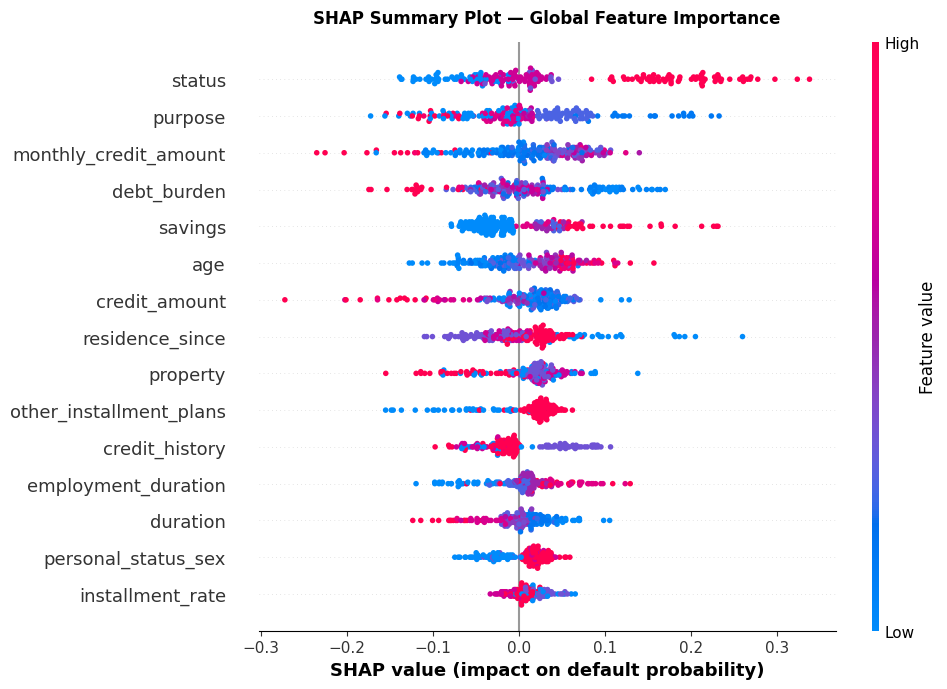


Reading guide:
- Top features = most impactful across ALL borrowers
- Red dots = borrowers with HIGH feature value
- Blue dots = borrowers with LOW feature value
- Dots far right = those borrowers got high default scores



In [4]:
# The classic SHAP dot plot — most informative global view
plot_shap_summary(shap_values, feature_names, max_display=15)

print("""
Reading guide:
- Top features = most impactful across ALL borrowers
- Red dots = borrowers with HIGH feature value
- Blue dots = borrowers with LOW feature value
- Dots far right = those borrowers got high default scores
""")

2026-05-19 17:12:48.768 | INFO     | explain:plot_shap_bar:199 - Saved: data/plots/shap_bar.png


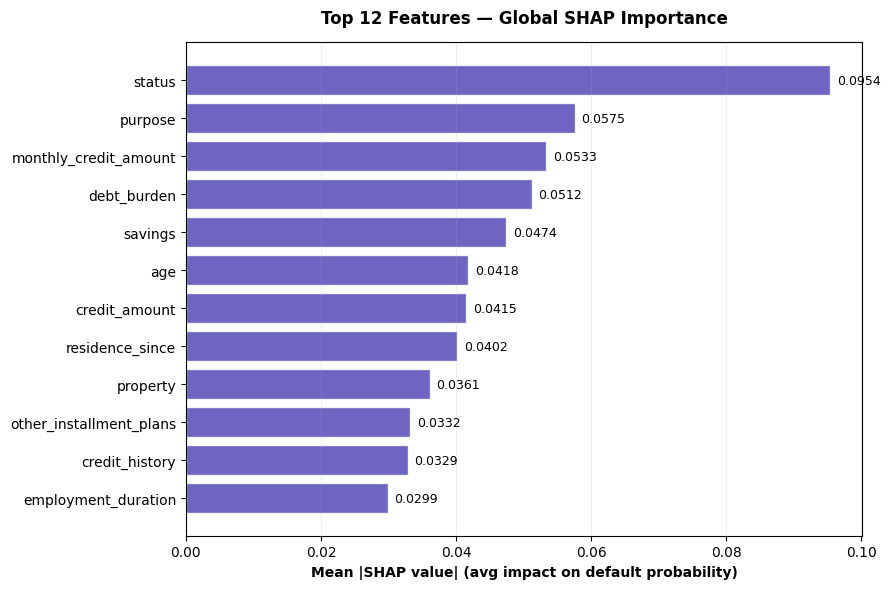

In [5]:
# Simpler version for presentations and dashboards
plot_shap_bar(shap_values, feature_names, top_n=12)

In [6]:
import pandas as pd

y_prob = model.predict_proba(X_test)[:, 1]

# Find a high-risk case (predicted default)
high_risk_idx = np.argmax(y_prob)

# Find a low-risk case (predicted no default)
low_risk_idx  = np.argmin(y_prob)

# Find a borderline case (prediction near 0.5)
borderline_idx = np.argmin(np.abs(y_prob - 0.5))

print(f"High-risk borrower   : index {high_risk_idx}, "
      f"P(default) = {y_prob[high_risk_idx]:.4f}, "
      f"Actual = {y_test.iloc[high_risk_idx]}")

print(f"Low-risk borrower    : index {low_risk_idx}, "
      f"P(default) = {y_prob[low_risk_idx]:.4f}, "
      f"Actual = {y_test.iloc[low_risk_idx]}")

print(f"Borderline borrower  : index {borderline_idx}, "
      f"P(default) = {y_prob[borderline_idx]:.4f}, "
      f"Actual = {y_test.iloc[borderline_idx]}")

High-risk borrower   : index 114, P(default) = 0.9990, Actual = 1
Low-risk borrower    : index 180, P(default) = 0.0322, Actual = 0
Borderline borrower  : index 7, P(default) = 0.5177, Actual = 0


=== HIGH-RISK BORROWER EXPLANATION ===


2026-05-19 17:12:49.296 | INFO     | explain:plot_waterfall:243 - Saved: data/plots/shap_waterfall_114.png


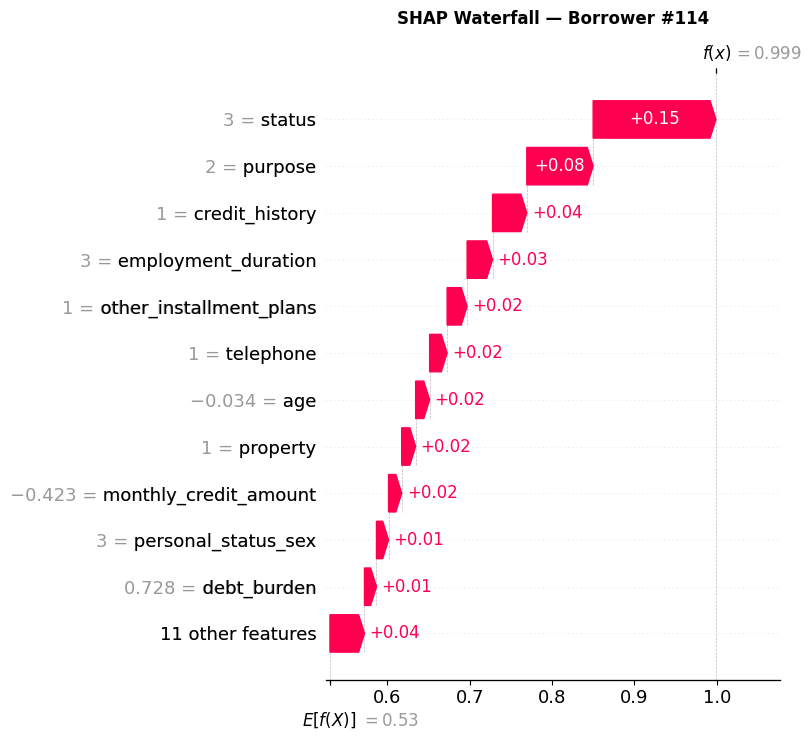

In [7]:
print("=== HIGH-RISK BORROWER EXPLANATION ===")
plot_waterfall(shap_values, feature_names, sample_idx=high_risk_idx)

=== LOW-RISK BORROWER EXPLANATION ===


2026-05-19 17:12:49.746 | INFO     | explain:plot_waterfall:243 - Saved: data/plots/shap_waterfall_180.png


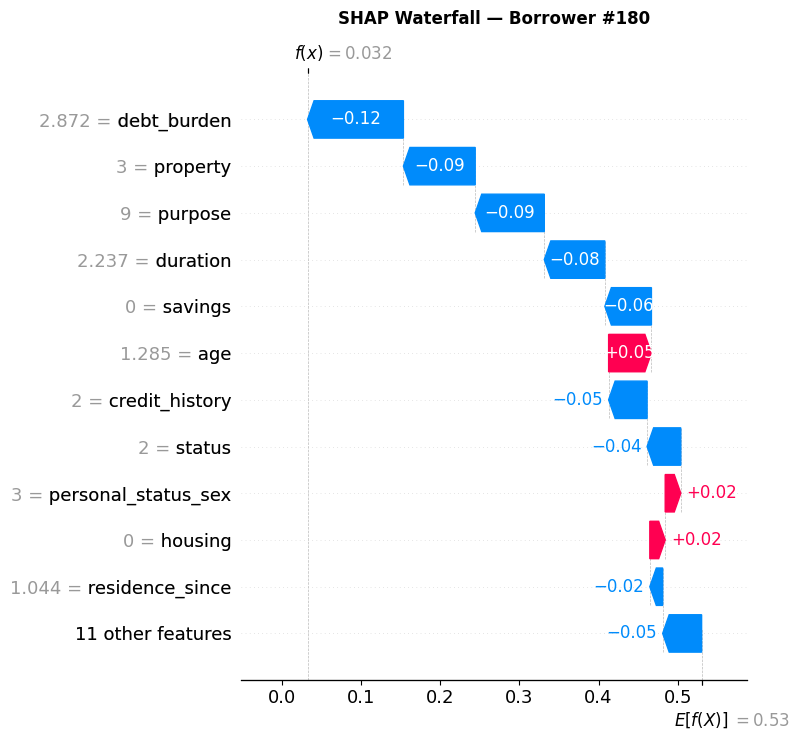

In [8]:
print("=== LOW-RISK BORROWER EXPLANATION ===")
plot_waterfall(shap_values, feature_names, sample_idx=low_risk_idx)

=== BORDERLINE BORROWER — Loan officer needs extra scrutiny ===


2026-05-19 17:12:50.130 | INFO     | explain:plot_waterfall:243 - Saved: data/plots/shap_waterfall_7.png


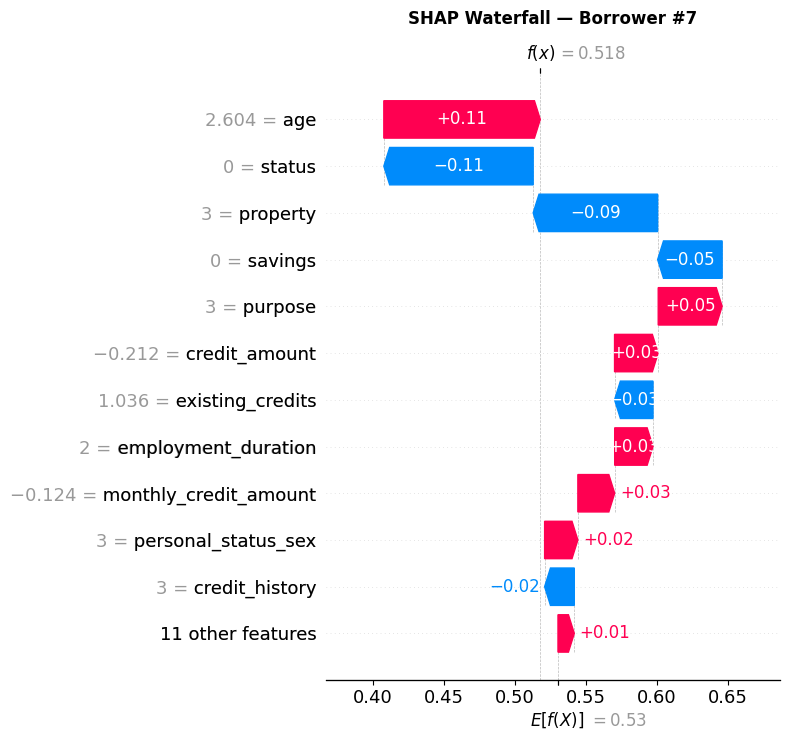

In [9]:
print("=== BORDERLINE BORROWER — Loan officer needs extra scrutiny ===")
plot_waterfall(shap_values, feature_names, sample_idx=borderline_idx)

In [10]:
# This renders as interactive HTML inside the notebook
force = plot_force(shap_values, feature_names, sample_idx=high_risk_idx)
force   # display the interactive plot

2026-05-19 17:12:50.243 | INFO     | explain:plot_force:277 - Saved: data/plots/shap_force_114.html


2026-05-19 17:20:54.395 | INFO     | explain:plot_dependence:320 - Saved: data/plots/shap_dependence_status.png


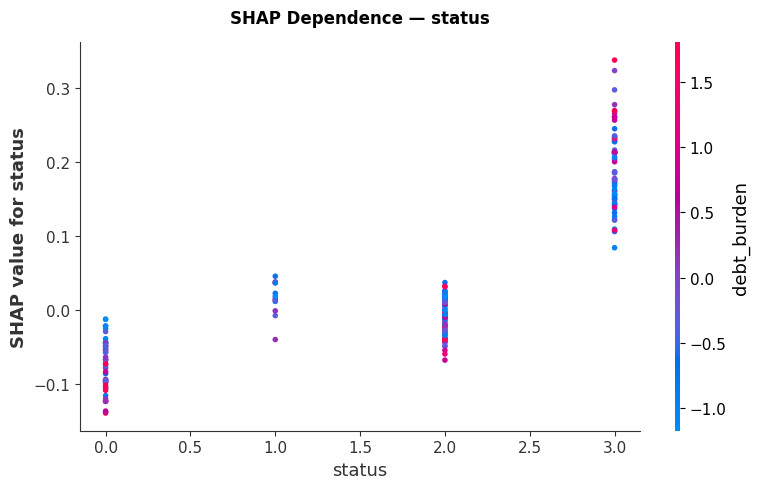

In [12]:
# How does checking_account status drive SHAP values?
plot_dependence(shap_values, feature_names, feature="status")

2026-05-19 17:21:04.519 | INFO     | explain:plot_dependence:320 - Saved: data/plots/shap_dependence_credit_amount.png


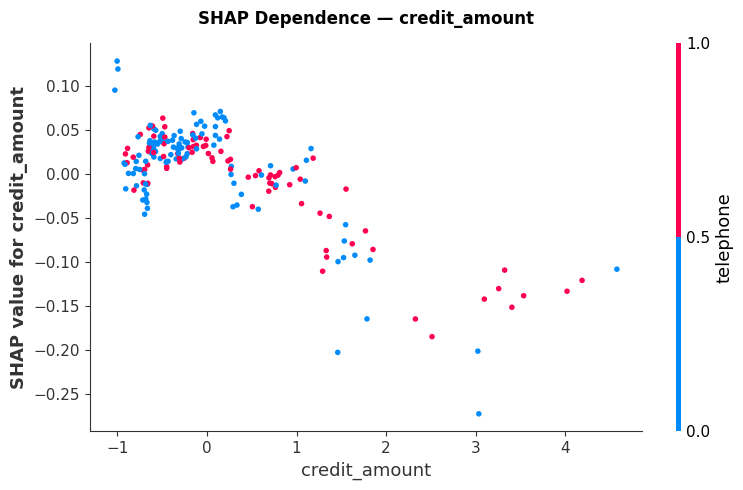

In [13]:
# How does credit_amount interact with other features?
plot_dependence(shap_values, feature_names, feature="credit_amount")

In [14]:
import json

# Simulate what the /explain endpoint returns
single_X    = X_test[high_risk_idx:high_risk_idx+1]
explanation = explain_single(model, explainer, single_X,
                              feature_names, top_n=8)

print("JSON explanation (what the API returns):")
print(json.dumps(explanation, indent=2))

JSON explanation (what the API returns):
{
  "base_value": 0.5302,
  "prediction": 0.999,
  "top_features": [
    {
      "feature": "status",
      "shap_value": 0.1491,
      "feature_value": "3.0",
      "direction": "increases_risk"
    },
    {
      "feature": "purpose",
      "shap_value": 0.0806,
      "feature_value": "2.0",
      "direction": "increases_risk"
    },
    {
      "feature": "credit_history",
      "shap_value": 0.0416,
      "feature_value": "1.0",
      "direction": "increases_risk"
    },
    {
      "feature": "employment_duration",
      "shap_value": 0.0309,
      "feature_value": "3.0",
      "direction": "increases_risk"
    },
    {
      "feature": "other_installment_plans",
      "shap_value": 0.0243,
      "feature_value": "1.0",
      "direction": "increases_risk"
    },
    {
      "feature": "telephone",
      "shap_value": 0.0213,
      "feature_value": "1.0",
      "direction": "increases_risk"
    },
    {
      "feature": "age",
      "shap_va

In [15]:
# Save the explainer so the API can load it at startup
joblib.dump(explainer, "../models/shap_explainer_v1.joblib")
print("Explainer saved: models/shap_explainer_v1.joblib")

Explainer saved: models/shap_explainer_v1.joblib


In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           PHASE 4 — SHAP EXPLAINABILITY SUMMARY              ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  GLOBAL INSIGHTS (test set of 200 borrowers)                 ║
║  Top predictors (by mean |SHAP|):                            ║
║  1. checking_account  — strongest default signal             ║
║  2. credit_history    — past behaviour predicts future       ║
║  3. credit_amount     — larger loans = more risk             ║
║  4. duration          — longer loans = more exposure         ║
║  5. savings_account   — savings buffer reduces risk          ║
║                                                              ║
║  LOCAL EXPLANATION                                           ║
║  Every borrower gets:                                        ║
║  • Waterfall plot (visual, notebook/dashboard)               ║
║  • Force plot (interactive HTML)                             ║
║  • JSON SHAP dict (API endpoint /explain)                    ║
║                                                              ║
║  REGULATORY USE                                              ║
║  SHAP values satisfy "right to explanation" requirements     ║
║  under GDPR Article 22 and ECOA adverse action notices       ║
║                                                              ║
║  ARTIFACTS SAVED                                             ║
║  models/shap_explainer_v1.joblib                             ║
║  data/plots/shap_summary.png                                 ║
║  data/plots/shap_bar.png                                     ║
║  data/plots/shap_waterfall_*.png                             ║
║  data/plots/shap_force_*.html                                ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")